In [5]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import mne
from mne.time_frequency import psd_array_welch

mne.set_log_level('WARNING')

DATASET_PATH = '/Users/arnavverma/ds004504-download' 
USE_DERIVATIVES = False
SFREQ_RESAMPLE = 256

FREQ_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4,   8),
    'Alpha': (8,  13),
    'Beta':  (13, 30),
    'Gamma': (30, 45),
}

GROUP_MAP    = {'A': 'AD', 'C': 'HC', 'F': 'FTD'}
GROUP_COLORS = {'AD': '#E63946', 'FTD': '#F4A261', 'HC': '#2A9D8F'}

print('MNE version:', mne.__version__)
print('Dataset path exists:', os.path.exists(DATASET_PATH))
print('✅ All good!')

MNE version: 1.12.1
Dataset path exists: True
✅ All good!


In [6]:
participants_path = os.path.join(DATASET_PATH, 'participants.tsv')
participants = pd.read_csv(participants_path, sep='\t')

participants['group'] = participants['Group'].map(GROUP_MAP)

print(f'Total subjects: {len(participants)}')
print(f"Groups: {participants['group'].value_counts().to_dict()}")
print()
print('MMSE and Age stats per group:')
print(participants.groupby('group')[['MMSE', 'Age']].agg(['mean', 'std']).round(2))

Total subjects: 88
Groups: {'AD': 36, 'HC': 29, 'FTD': 23}

MMSE and Age stats per group:
        MMSE          Age      
        mean   std   mean   std
group                          
AD     17.75  4.50  66.39  7.89
FTD    22.17  2.64  63.65  8.22
HC     30.00  0.00  67.90  5.40


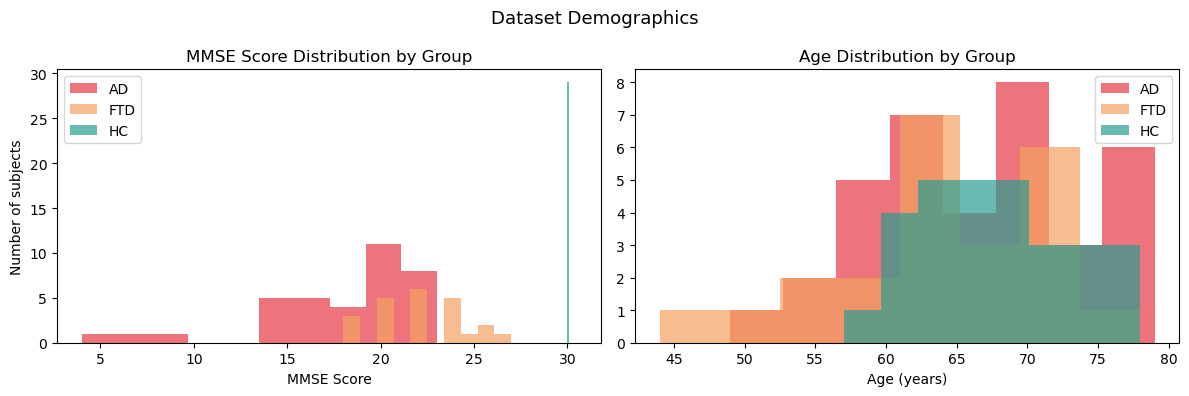

Saved: demographics.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for grp, grp_df in participants.groupby('group'):
    axes[0].hist(grp_df['MMSE'], alpha=0.7, label=grp,
                 color=GROUP_COLORS[grp], bins=10)
axes[0].set_xlabel('MMSE Score')
axes[0].set_ylabel('Number of subjects')
axes[0].set_title('MMSE Score Distribution by Group')
axes[0].legend()

for grp, grp_df in participants.groupby('group'):
    axes[1].hist(grp_df['Age'], alpha=0.7, label=grp,
                 color=GROUP_COLORS[grp], bins=8)
axes[1].set_xlabel('Age (years)')
axes[1].set_title('Age Distribution by Group')
axes[1].legend()

plt.suptitle('Dataset Demographics', fontsize=13)
plt.tight_layout()
plt.savefig('demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: demographics.png')

In [8]:
def load_subject_eeg(subject_id, dataset_path):
    try:
        pattern = os.path.join(
            dataset_path, subject_id, 'eeg',
            f'{subject_id}_task-eyesclosed_eeg.set'
        )
        files = glob.glob(pattern)
        if not files:
            print(f'  [WARN] No file found for {subject_id}')
            return None
        raw = mne.io.read_raw_eeglab(files[0], preload=True, verbose=False)
        return raw
    except Exception as e:
        print(f'  [ERROR] {subject_id}: {e}')
        return None


def preprocess_raw(raw, sfreq=256):
    raw = raw.copy()
    raw.resample(sfreq, verbose=False)
    raw.filter(0.5, 45.0, fir_design='firwin', verbose=False)
    raw.set_eeg_reference('average', projection=True, verbose=False)
    raw.apply_proj(verbose=False)
    return raw


print('Loading EEG files...\n')
all_raws = {}

for _, row in participants.iterrows():
    sub_id = row['participant_id']
    raw = load_subject_eeg(sub_id, DATASET_PATH)

    if raw is not None:
        raw = preprocess_raw(raw, SFREQ_RESAMPLE)
        all_raws[sub_id] = raw
        print(f'  ✅ {sub_id} ({row["group"]}) — '
              f'{len(raw.ch_names)} ch, '
              f'{raw.times[-1]:.0f} sec')

print(f'\nLoaded {len(all_raws)} / {len(participants)} subjects.')

Loading EEG files...

  ✅ sub-001 (AD) — 19 ch, 600 sec
  ✅ sub-002 (AD) — 19 ch, 793 sec
  ✅ sub-003 (AD) — 19 ch, 307 sec
  ✅ sub-004 (AD) — 19 ch, 707 sec
  ✅ sub-005 (AD) — 19 ch, 804 sec
  ✅ sub-006 (AD) — 19 ch, 637 sec
  ✅ sub-007 (AD) — 19 ch, 769 sec
  ✅ sub-008 (AD) — 19 ch, 799 sec
  ✅ sub-009 (AD) — 19 ch, 614 sec
  ✅ sub-010 (AD) — 19 ch, 1291 sec
  ✅ sub-011 (AD) — 19 ch, 772 sec
  ✅ sub-012 (AD) — 19 ch, 898 sec
  ✅ sub-013 (AD) — 19 ch, 840 sec
  ✅ sub-014 (AD) — 19 ch, 945 sec
  ✅ sub-015 (AD) — 19 ch, 910 sec
  ✅ sub-016 (AD) — 19 ch, 985 sec
  ✅ sub-017 (AD) — 19 ch, 847 sec
  ✅ sub-018 (AD) — 19 ch, 847 sec
  ✅ sub-019 (AD) — 19 ch, 920 sec
  ✅ sub-020 (AD) — 19 ch, 869 sec
  ✅ sub-021 (AD) — 19 ch, 923 sec
  ✅ sub-022 (AD) — 19 ch, 824 sec
  ✅ sub-023 (AD) — 19 ch, 863 sec
  ✅ sub-024 (AD) — 19 ch, 767 sec
  ✅ sub-025 (AD) — 19 ch, 698 sec
  ✅ sub-026 (AD) — 19 ch, 917 sec
  ✅ sub-027 (AD) — 19 ch, 831 sec
  ✅ sub-028 (AD) — 19 ch, 826 sec
  ✅ sub-029 (AD) — 19 ch,

In [18]:
def compute_band_powers(raw, freq_bands, fmin=0.5, fmax=45.0):
    """
    Compute relative band power per channel for one subject.
    Retruns a dict: {'Delta': array(19,), 'Theta': array(19,), ...}
    """
    data=raw.get_data()
    sfreq=raw.info['sfreq']
    psds,freqs=psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        n_fft=int(sfreq*4),
        n_overlap=int(sfreq*2),
        verbose=False
    )
    total_power=psds.sum(axis=1, keepdims=True)
    band_powers={}
    for band_name, (lo,hi) in freq_bands.items():
        idx=np.where((freqs>=lo)&(freqs<hi))[0]
        bp=psds[:,idx].sum(axis=1)
        band_powers[band_name]=bp/total_power.squeeze()
    return band_powers
print('Computing band powers for all subjects...')
print('(This will take 1-2 mintues)\n')
results=[]
for _, row in participants.iterrows():
    sub_id=row['participant_id']
    if sub_id not in all_raws:
        continue
    bp = compute_band_powers(all_raws[sub_id], FREQ_BANDS)
    ch_names=all_raws[sub_id].ch_names
    for ch_idx, ch_name in enumerate(ch_names):
        entry={
            'subject':sub_id,
            'group':  row['group'],
            'MMSE':   row['MMSE'],
            'Age':    row['Age'],
            'channel':ch_name,
        }
        for band_name in FREQ_BANDS:
            entry[band_name]=bp[band_name][ch_idx]
        results.append(entry)
        print(f' ✅ {sub_id} ({row["group"]}done')
df=pd.DataFrame(results)
print(f'\nFeature table shape:{df.shape}')
print(f'Rows={len(all_raws)}subjects x 19 channels={len(all_raws)*19}')
print(df.head())        

Computing band powers for all subjects...
(This will take 1-2 mintues)

 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-001 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-002 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdone
 ✅ sub-003 (ADdo

Mean band power per group:
       Delta  Theta  Alpha   Beta  Gamma
group                                   
AD     0.661  0.112  0.121  0.071  0.036
FTD    0.650  0.094  0.126  0.085  0.044
HC     0.593  0.060  0.214  0.101  0.031


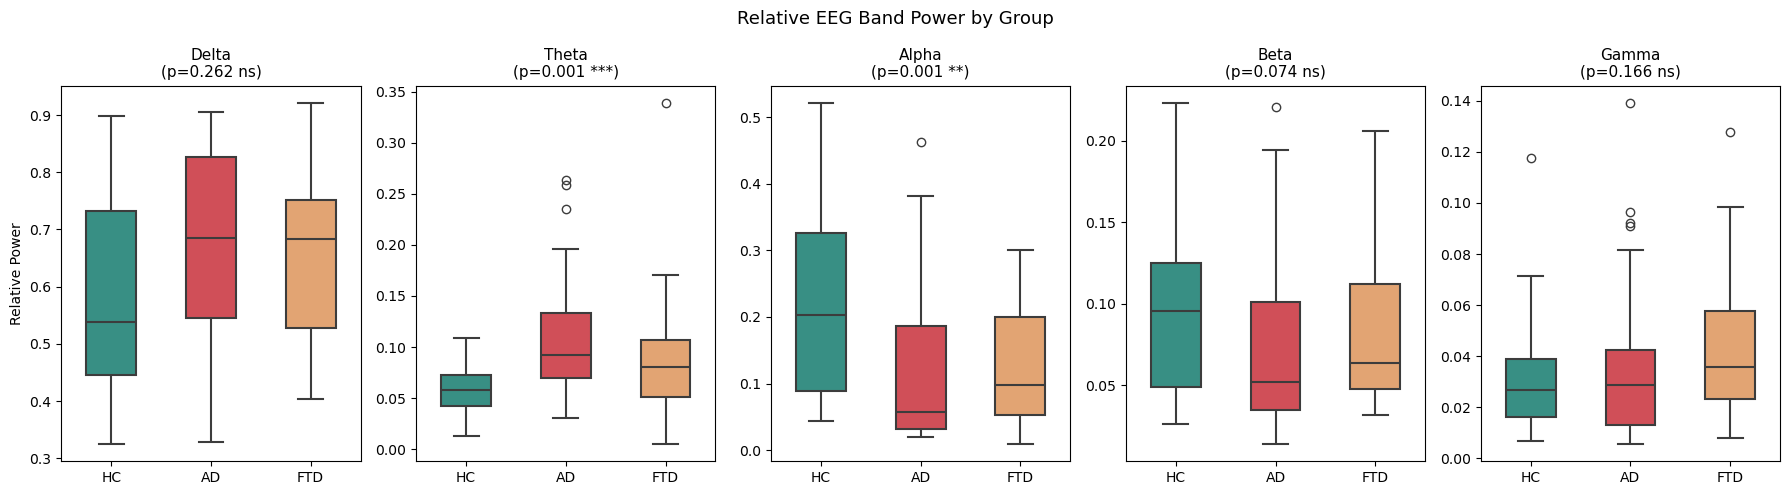

Saved : band_power_comparison.png


In [23]:
df_subj=df.groupby(['subject','group','MMSE','Age'])[list(FREQ_BANDS.keys())].mean().reset_index()
print('Mean band power per group:')
print(df_subj.groupby('group')[list(FREQ_BANDS.keys())].mean().round(3))
group_order=['HC','AD','FTD']
palette={g:GROUP_COLORS[g] for g in group_order}
fig,axes=plt.subplots(1, len(FREQ_BANDS), figsize=(18, 5))
for ax, band in zip(axes, FREQ_BANDS.keys()):
    sns.boxplot(
        data=df_subj, x='group', y=band,
        order=group_order, palette=palette,
        width=0.5,linewidth=1.5,ax=ax
    )
    group_data=[df_subj[df_subj['group']==g][band].values for g in group_order]
    stat,p=stats.kruskal(*group_data)
    if p<0.001:
        sig='***'
    elif p<0.01:
        sig='**'
    elif p<0.05:
        sig='*'
    else:
        sig='ns'
    ax.set_title(f'{band}\n(p={p:.3f} {sig})', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Relative Power' if band=='Delta' else '')
fig.suptitle('Relative EEG Band Power by Group', fontsize=13)
plt.tight_layout()
plt.savefig('band_power_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved : band_power_comparison.png')

Mean Theta/Alpha Ratio per group:
        mean    std
group              
AD     1.965  1.426
FTD    1.153  0.951
HC     0.420  0.378


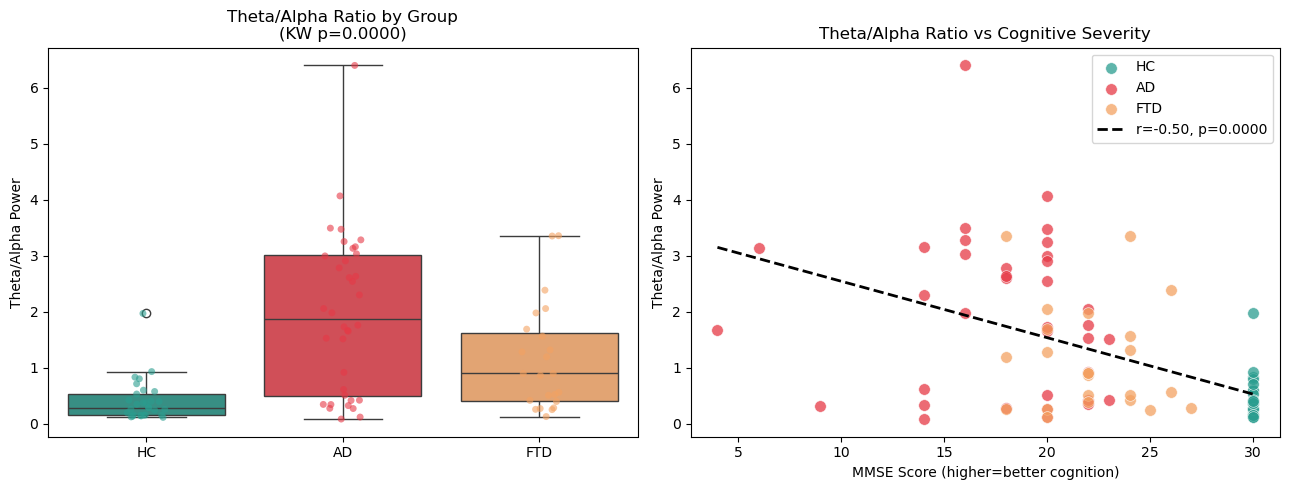


Correlation with MMSE: r=-0.501, p=0.000001
Interpretation:
r < 0 means higher MMSE (better cognition) = lower theta/alpha ratio


In [28]:
df_subj['Theta_Alpha_Ratio']=df_subj['Theta']/ (df_subj['Alpha'] + 1e-10)
print('Mean Theta/Alpha Ratio per group:')
print(df_subj.groupby('group')['Theta_Alpha_Ratio'].agg(['mean', 'std']).round(3))
fig, axes=plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(
    data=df_subj, x='group', y='Theta_Alpha_Ratio',
    order=group_order, palette=palette, ax=axes[0]
)
sns.stripplot(
    data=df_subj, x='group', y='Theta_Alpha_Ratio',
    order=group_order, palette=palette,
    alpha=0.6, size=5, jitter=True, ax=axes[0]
)
axes[0].set_ylabel('Theta/Alpha Power')
axes[0].set_xlabel('')
group_data=[df_subj[df_subj['group'] ==g]['Theta_Alpha_Ratio'].values for g in group_order]
stat, p=stats.kruskal(*group_data)
axes[0].set_title(f'Theta/Alpha Ratio by Group\n(KW p={p:.4f})')
for grp in group_order:
    sub=df_subj[df_subj['group'] ==grp]
    axes[1].scatter(
        sub['MMSE'], sub['Theta_Alpha_Ratio'],
        label=grp, color=GROUP_COLORS[grp],
        alpha=0.75, s=70, edgecolors='white', linewidth=0.5
    )
    slope, intercept, r, p_corr, _=stats.linregress(
        df_subj['MMSE'], df_subj['Theta_Alpha_Ratio']
    )
x_line=np.linspace(df_subj['MMSE'].min(), df_subj['MMSE'].max(),100)
axes[1].plot(x_line, slope * x_line + intercept,
             'k--', linewidth=2, label=f'r={r:.2f}, p={p_corr:.4f}')
axes[1].set_xlabel('MMSE Score (higher=better cognition)')
axes[1].set_ylabel('Theta/Alpha Power')
axes[1].set_title('Theta/Alpha Ratio vs Cognitive Severity')
axes[1].legend()
plt.tight_layout()
plt.savefig('theta_aplha_vs_mmse.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCorrelation with MMSE: r={r:.3f}, p={p_corr:.6f}')
print('Interpretation:')
print('r < 0 means higher MMSE (better cognition) = lower theta/alpha ratio')
    

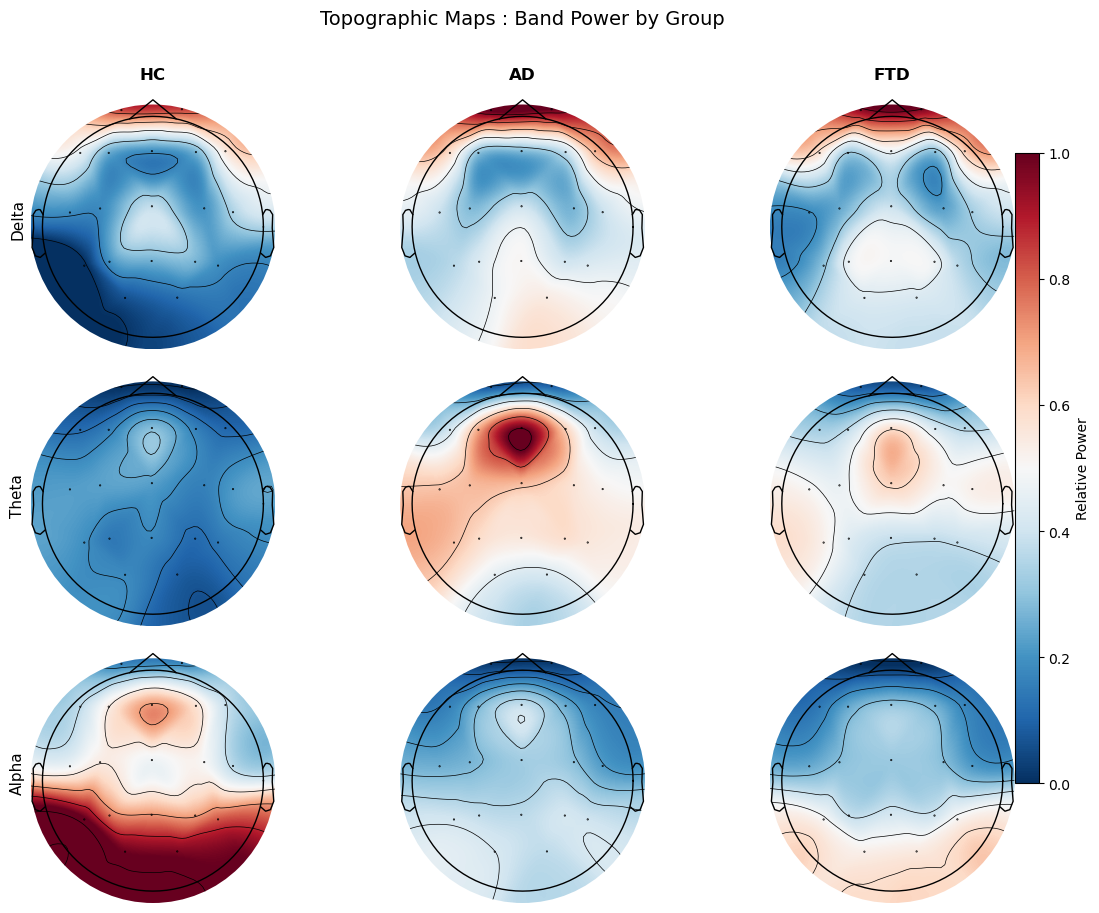

Saved : topomaps.png


In [36]:
sample_raw=list(all_raws.values())[0].copy()
montage=mne.channels.make_standard_montage('standard_1020')
sample_raw.set_montage(montage, on_missing='ignore', verbose=False)
info=sample_raw.info
plot_bands=['Delta', 'Theta', 'Alpha']
plot_groups=['HC', 'AD', 'FTD']
fig, axes=plt.subplots(
    len(plot_bands), len(plot_groups),
    figsize=(12, 9)
)
for row_idx, band in enumerate(plot_bands):
    all_vals=[]
    for grp in plot_groups:
        grp_ch=df[df['group'] ==grp].groupby('channel')[band].mean()
        all_vals.append(grp_ch)
    vmin=min(v.min() for v in all_vals)
    vmax=max(v.max() for v in all_vals)
    for col_idx, grp in enumerate(plot_groups):
        ax=axes[row_idx, col_idx]
        ch_power=all_vals[col_idx]
        data_ordered=np.array([
            ch_power.get(ch, np.nan) for ch in sample_raw.ch_names
        ])
        mne.viz.plot_topomap(
            data_ordered, info,
            axes=ax,
            vlim=(vmin, vmax),
            cmap='RdBu_r',
            show=False,
            sphere=(0, 0, 0, 0.095)
        )
        if row_idx ==0:
            ax.set_title(grp, fontsize=12, fontweight='bold')
        if col_idx ==0:
            ax.set_ylabel(band, fontsize=11)
fig.subplots_adjust(right=0.88)
cbar_ax=fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm=plt.cm.ScalarMappable(cmap='RdBu_r')
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Relative Power')
fig.suptitle('Topographic Maps : Band Power by Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('topomaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved : topomaps.png')

In [52]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
feature_rows=[]
for _, row in participants.iterrows():
    sub_id=row['participant_id']
    if sub_id not in all_raws:
        continue
    sub_df=df[df['subject'] ==sub_id]
    entry={'subject':sub_id, 'group': row['group']}
    for band in FREQ_BANDS.keys():
        for ch in sorted(sub_df['channel'].unique()):
            val=float(sub_df[sub_df['channel']==ch][band].values[0])
            entry[f'{band}_{ch}']=val
    feature_rows.append(entry)
feat_df=pd.DataFrame(feature_rows)
feature_cols=[c for c in feat_df.columns if c not in['subject', 'group']]
x=feat_df[feature_cols].fillna(0).values
y=feat_df['group'].values
print(f'Feature matrix: {x.shape}')
print(f'Classes: {np.unique(y)}')
print(f'Subjects per class: AD={sum(y=="AD")}, FTD={sum(y=="FTD")}, HC={sum(y=="HC")}')
              

Feature matrix: (88, 95)
Classes: ['AD' 'FTD' 'HC']
Subjects per class: AD=36, FTD=23, HC=29


In [55]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mask=np.isin(y, ['AD','HC'])
x_bin=x[mask]
y_bin=y[mask]
svm=Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, random_state=42))
])
svm_scores=cross_val_score(svm, x_bin, y_bin, cv=cv, scoring='balanced_accuracy')
print(f'SVM (AD vs HC)')
print(f' Balanced Accuracy: {svm_scores.mean():.3f} ± {svm_scores.std():.3f}')
print(f' Per fold: {np.round(svm_scores, 3)}')
print()
rf=Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_scores=cross_val_score(rf, x, y, cv=cv, scoring='balanced_accuracy')
print(f'Random Forest (AD vs FTD vs HC)')
print(f' Balanced Accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
print(f' Per fold: {np.round(rf_scores, 3)}')

SVM (AD vs HC)
 Balanced Accuracy: 0.724 ± 0.128
 Per fold: [0.8   0.679 0.917 0.69  0.536]

Random Forest (AD vs FTD vs HC)
 Balanced Accuracy: 0.474 ± 0.112
 Per fold: [0.492 0.649 0.416 0.504 0.31 ]


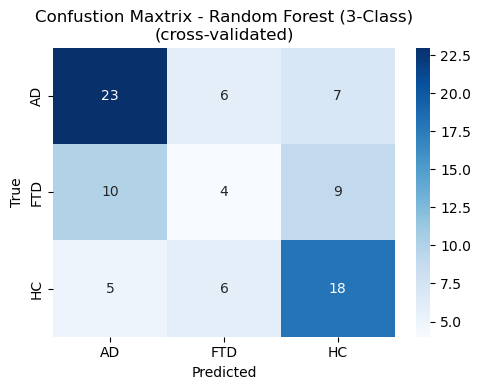

Saved: confusion_matrix_cv.png


In [59]:
from sklearn.model_selection import cross_val_predict
y_pred_cv=cross_val_predict(rf, x, y, cv=cv)
cm=confusion_matrix(y, y_pred_cv, labels=['AD', 'FTD', 'HC'])
fig, ax=plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['AD', 'FTD', 'HC'],
            yticklabels=['AD', 'FTD', 'HC'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confustion Maxtrix - Random Forest (3-Class)\n(cross-validated)')
plt.tight_layout()
plt.savefig('confusion_matrix_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_cv.png')

In [65]:
from mne_connectivity import spectral_connectivity_epochs
def compute_plv(raw, fmin=8.0, fmax=13.0, epoch_length=2.0):
    """
    Compute mean PLV in the alpha band for all channel pairs.
    Returns a connectivity matrix (n_channels x n_channels)
    """
    epochs=mne.make_fixed_length_epochs(
    raw, duration=epoch_length,
    preload=True, verbose=False
    )
    conn=spectral_connectivity_epochs(
       epochs, 
       method='plv',
       mode='multitaper',
       fmin=fmin,
       fmax=fmax,
       faverage=True,
       verbose=False
    )
    plv_matrix=conn.get_data(output='dense')[:, :, 0]
    return plv_matrix
print('Computing PLV for all subejcts...')
print('(This will take 3-5 minutes)\n')
plv_by_group={'AD' : [], 'FTD' : [], 'HC' : []}
for _, row in participants.iterrows():
    sub_id=row['participant_id']
    grp=row['group']
    if sub_id not in all_raws:
        continue
    print(f'Computing {sub_id} ({grp})...')
    plv=compute_plv(all_raws[sub_id])
    plv_by_group[grp].append(plv)
mean_plv={grp: np.mean(matrices, axis=0)
          for grp, matrices in plv_by_group.items()
          if matrices}
print('\n PLV computation complete!')
print(f'Matrix Shape: {mean_plv["HC"].shape}')

Computing PLV for all subejcts...
(This will take 3-5 minutes)

Computing sub-001 (AD)...
Computing sub-002 (AD)...
Computing sub-003 (AD)...
Computing sub-004 (AD)...
Computing sub-005 (AD)...
Computing sub-006 (AD)...
Computing sub-007 (AD)...
Computing sub-008 (AD)...
Computing sub-009 (AD)...
Computing sub-010 (AD)...
Computing sub-011 (AD)...
Computing sub-012 (AD)...
Computing sub-013 (AD)...
Computing sub-014 (AD)...
Computing sub-015 (AD)...
Computing sub-016 (AD)...
Computing sub-017 (AD)...
Computing sub-018 (AD)...
Computing sub-019 (AD)...
Computing sub-020 (AD)...
Computing sub-021 (AD)...
Computing sub-022 (AD)...
Computing sub-023 (AD)...
Computing sub-024 (AD)...
Computing sub-025 (AD)...
Computing sub-026 (AD)...
Computing sub-027 (AD)...
Computing sub-028 (AD)...
Computing sub-029 (AD)...
Computing sub-030 (AD)...
Computing sub-031 (AD)...
Computing sub-032 (AD)...
Computing sub-033 (AD)...
Computing sub-034 (AD)...
Computing sub-035 (AD)...
Computing sub-036 (AD)...


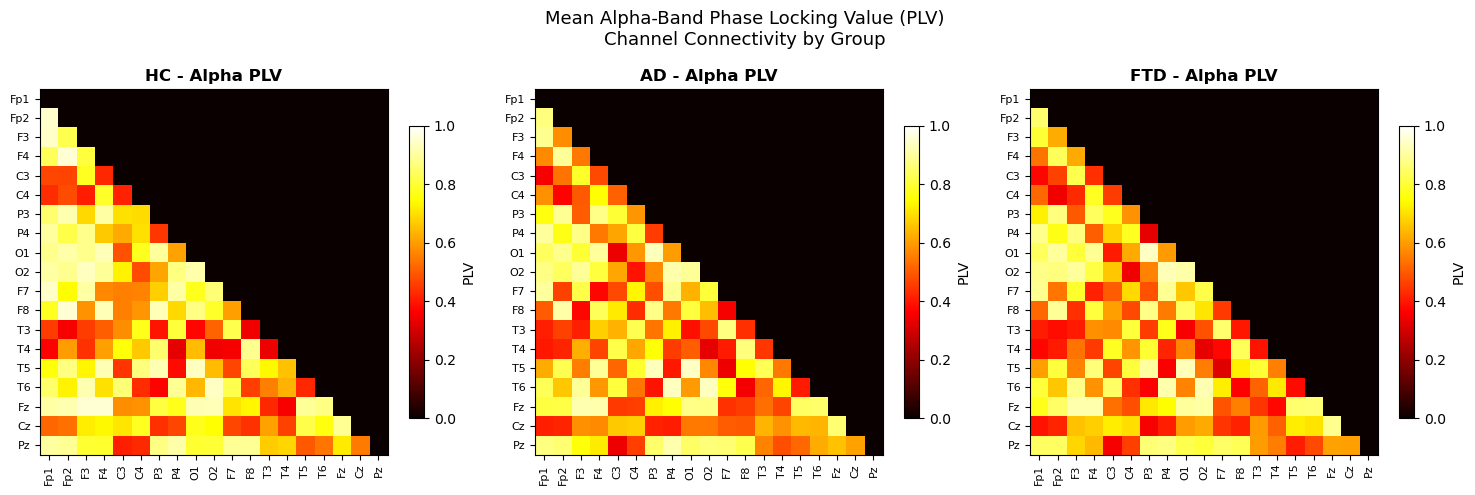

Saved : plv_matrices.png


In [68]:
ch_labels=list(all_raws.values())[0].ch_names
fig, axes=plt.subplots(1, 3, figsize=(15, 5))
for ax, grp in zip(axes, ['HC', 'AD', 'FTD']):
    im=ax.imshow(mean_plv[grp], cmap='hot', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'{grp} - Alpha PLV', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(ch_labels)))
    ax.set_yticks(range(len(ch_labels)))
    ax.set_xticklabels(ch_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(ch_labels, fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8, label='PLV')
fig.suptitle('Mean Alpha-Band Phase Locking Value (PLV)\nChannel Connectivity by Group', fontsize=13)
plt.tight_layout()
plt.savefig('plv_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved : plv_matrices.png')
    

Mean alpha PLV per group:
       mean  std
group           
AD      0.0  0.0
FTD     0.0  0.0
HC      0.0  0.0

Kruskal-Wallis: p = nan
Correlation with MMSE: r = nan, p = nan


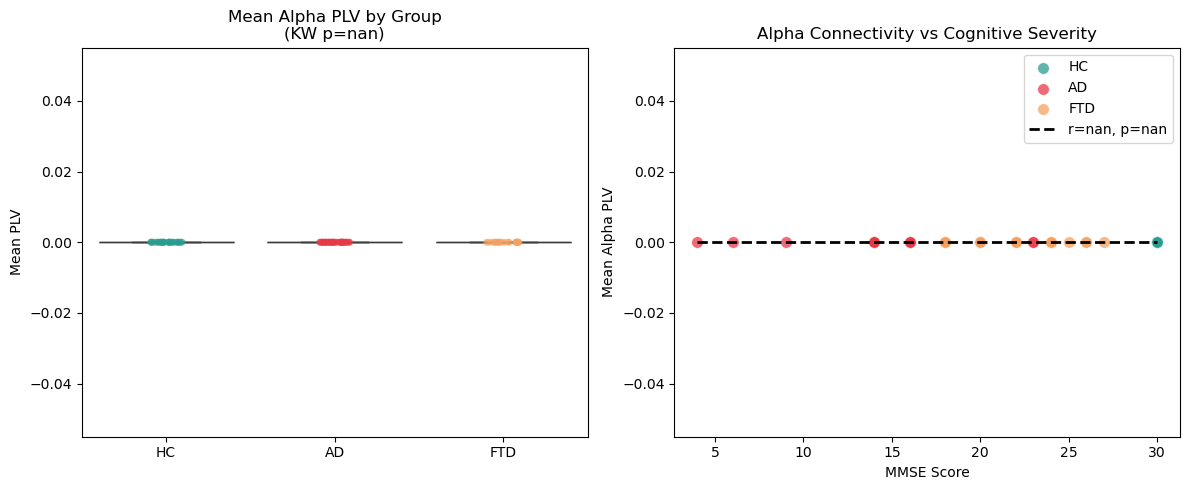

Saved: plv_vs_mmse.png


In [73]:
plv_scores=[]
for _, row in participants.iterrows():
    sub_id=row['participant_id']
    grp=row['group']
    if sub_id not in all_raws:
        continue 
    plv=plv_by_group[grp][
       [i for i, r in enumerate(participants[participants['group']==grp]['participant_id'])
        if r==sub_id][0]
    ]
    upper=plv[np.triu_indices(19, k=1)]
    plv_scores.append({
        'subject': sub_id,
        'group': grp,
        'mean_plv': upper.mean(),
        'MMSE': row['MMSE']
    })
plv_df=pd.DataFrame(plv_scores)
print('Mean alpha PLV per group:')
print(plv_df.groupby('group')['mean_plv'].agg(['mean','std']).round(3))
groups_plv=[plv_df[plv_df['group']==g]['mean_plv'].values for g in ['HC', 'AD', 'FTD']]
stat, p=stats.kruskal(*groups_plv)
print(f'\nKruskal-Wallis: p = {p:.4f}')
slope, intercept, r, p_corr, _= stats.linregress(plv_df['MMSE'], plv_df['mean_plv'])
print(f'Correlation with MMSE: r = {r:.3f}, p = {p_corr:.6f}')
fig, axes=plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=plv_df, x='group', y='mean_plv',
            order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS, ax=axes[0])
sns.stripplot(data=plv_df, x='group', y='mean_plv',
              order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS,
              alpha=0.6, size=5, jitter=True, ax=axes[0])
axes[0].set_title(f'Mean Alpha PLV by Group\n(KW p={p:.4f})')
axes[0].set_ylabel('Mean PLV')
axes[0].set_xlabel('')
for grp in ['HC', 'AD', 'FTD']:
    sub=plv_df[plv_df['group'] == grp]
    axes[1].scatter(sub['MMSE'], sub['mean_plv'],
                    label=grp, color=GROUP_COLORS[grp],
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
x_line=np.linspace(plv_df['MMSE'].min(), plv_df['MMSE'].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept,
             'k--', linewidth=2, label=f'r={r:.2f}, p={p_corr:.4f}')
axes[1].set_xlabel('MMSE Score')
axes[1].set_ylabel('Mean Alpha PLV')
axes[1].set_title('Alpha Connectivity vs Cognitive Severity')
axes[1].legend()
plt.tight_layout()
plt.savefig('plv_vs_mmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plv_vs_mmse.png')
    
        
    

In [74]:
for grp in ['AD', 'FTD', 'HC']:
    print(f'{grp}: {len(plv_by_group[grp])} matrices')
    if plv_by_group[grp]:
        print(f'  First matrix sample value: {plv_by_group[grp][0][0,1]:.4f}')

AD: 36 matrices
  First matrix sample value: 0.0000
FTD: 23 matrices
  First matrix sample value: 0.0000
HC: 29 matrices
  First matrix sample value: 0.0000


In [75]:
test_raw = list(all_raws.values())[0]
test_epochs = mne.make_fixed_length_epochs(
    test_raw, duration=2.0, preload=True, verbose=False
)

conn = spectral_connectivity_epochs(
    test_epochs,
    method='plv',
    mode='multitaper',
    fmin=8.0,
    fmax=13.0,
    faverage=True,
    verbose=False
)

print('conn data shape:', conn.get_data().shape)
print('Sample values:', conn.get_data()[:10, 0])
print('Max value:', conn.get_data().max())
print('Non-zero values:', np.count_nonzero(conn.get_data()))

conn data shape: (361, 1)
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max value: 0.9860907150081222
Non-zero values: 171


In [80]:
def compute_plv(raw, fmin=8.0, fmax=13.0, epoch_length=2.0):
    epochs = mne.make_fixed_length_epochs(
        raw, duration=epoch_length,
        preload=True, verbose=False
    )
    conn = spectral_connectivity_epochs(
        epochs,
        method='plv',
        mode='multitaper',
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        verbose=False
    )

    n_ch = 19
    data_flat = conn.get_data()[:, 0]  
    plv_matrix = np.zeros((n_ch, n_ch))
    idx = 0
    for i in range(n_ch):
        for j in range(n_ch):
            plv_matrix[i, j] = data_flat[idx]
            idx += 1
    plv_matrix = plv_matrix + plv_matrix.T
    np.fill_diagonal(plv_matrix, 1.0) 

    return plv_matrix
print('Recomputing PLV...\n')
plv_by_group = {'AD': [], 'FTD': [], 'HC': []}

for _, row in participants.iterrows():
    sub_id = row['participant_id']
    grp = row['group']
    if sub_id not in all_raws:
        continue
    plv = compute_plv(all_raws[sub_id])
    plv_by_group[grp].append(plv)
    print(f'{sub_id} ({grp}) — mean PLV: {plv[np.triu_indices(19, k=1)].mean():.3f}')

mean_plv = {grp: np.mean(matrices, axis=0)
            for grp, matrices in plv_by_group.items()
            if matrices}

print(f'\n Done!')
print(f'HC mean PLV: {mean_plv["HC"][np.triu_indices(19,k=1)].mean():.4f}')
print(f'AD mean PLV: {mean_plv["AD"][np.triu_indices(19,k=1)].mean():.4f}')
print(f'FTD mean PLV: {mean_plv["FTD"][np.triu_indices(19,k=1)].mean():.4f}')

Recomputing PLV...

sub-001 (AD) — mean PLV: 0.686
sub-002 (AD) — mean PLV: 0.691
sub-003 (AD) — mean PLV: 0.713
sub-004 (AD) — mean PLV: 0.618
sub-005 (AD) — mean PLV: 0.661
sub-006 (AD) — mean PLV: 0.790
sub-007 (AD) — mean PLV: 0.608
sub-008 (AD) — mean PLV: 0.602
sub-009 (AD) — mean PLV: 0.768
sub-010 (AD) — mean PLV: 0.639
sub-011 (AD) — mean PLV: 0.600
sub-012 (AD) — mean PLV: 0.593
sub-013 (AD) — mean PLV: 0.585
sub-014 (AD) — mean PLV: 0.621
sub-015 (AD) — mean PLV: 0.719
sub-016 (AD) — mean PLV: 0.586
sub-017 (AD) — mean PLV: 0.650
sub-018 (AD) — mean PLV: 0.681
sub-019 (AD) — mean PLV: 0.596
sub-020 (AD) — mean PLV: 0.697
sub-021 (AD) — mean PLV: 0.655
sub-022 (AD) — mean PLV: 0.646
sub-023 (AD) — mean PLV: 0.675
sub-024 (AD) — mean PLV: 0.667
sub-025 (AD) — mean PLV: 0.766
sub-026 (AD) — mean PLV: 0.579
sub-027 (AD) — mean PLV: 0.590
sub-028 (AD) — mean PLV: 0.669
sub-029 (AD) — mean PLV: 0.611
sub-030 (AD) — mean PLV: 0.580
sub-031 (AD) — mean PLV: 0.710
sub-032 (AD) — mean

Mean alpha PLV per group:
        mean    std
group              
AD     0.653  0.056
FTD    0.644  0.060
HC     0.698  0.051

Kruskal-Wallis: p = 0.0008
Correlation with MMSE: r = 0.285, p = 0.007221


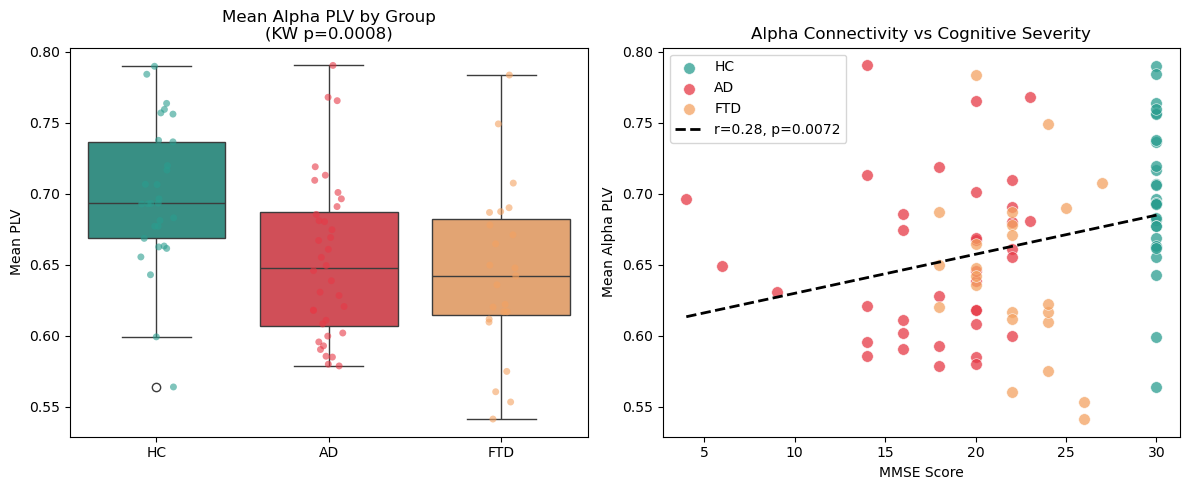

Saved: plv_vs_mmse.png


In [81]:
plv_scores = []

for grp in ['AD', 'FTD', 'HC']:
    grp_participants = participants[participants['group'] == grp]['participant_id'].tolist()
    matrices = plv_by_group[grp]

    for i, sub_id in enumerate(grp_participants):
        if i >= len(matrices):
            break
        plv = matrices[i]
        upper = plv[np.triu_indices(19, k=1)]
        mmse = participants[participants['participant_id'] == sub_id]['MMSE'].values[0]
        plv_scores.append({
            'subject': sub_id,
            'group': grp,
            'mean_plv': upper.mean(),
            'MMSE': mmse
        })

plv_df = pd.DataFrame(plv_scores)

print('Mean alpha PLV per group:')
print(plv_df.groupby('group')['mean_plv'].agg(['mean', 'std']).round(3))

groups_plv = [plv_df[plv_df['group'] == g]['mean_plv'].values for g in ['HC', 'AD', 'FTD']]
stat, p = stats.kruskal(*groups_plv)
print(f'\nKruskal-Wallis: p = {p:.4f}')

slope, intercept, r, p_corr, _ = stats.linregress(plv_df['MMSE'], plv_df['mean_plv'])
print(f'Correlation with MMSE: r = {r:.3f}, p = {p_corr:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=plv_df, x='group', y='mean_plv',
            order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS, ax=axes[0])
sns.stripplot(data=plv_df, x='group', y='mean_plv',
              order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS,
              alpha=0.6, size=5, jitter=True, ax=axes[0])
axes[0].set_title(f'Mean Alpha PLV by Group\n(KW p={p:.4f})')
axes[0].set_ylabel('Mean PLV')
axes[0].set_xlabel('')

for grp in ['HC', 'AD', 'FTD']:
    sub = plv_df[plv_df['group'] == grp]
    axes[1].scatter(sub['MMSE'], sub['mean_plv'],
                    label=grp, color=GROUP_COLORS[grp],
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)

x_line = np.linspace(plv_df['MMSE'].min(), plv_df['MMSE'].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept,
             'k--', linewidth=2, label=f'r={r:.2f}, p={p_corr:.4f}')
axes[1].set_xlabel('MMSE Score')
axes[1].set_ylabel('Mean Alpha PLV')
axes[1].set_title('Alpha Connectivity vs Cognitive Severity')
axes[1].legend()

plt.tight_layout()
plt.savefig('plv_vs_mmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plv_vs_mmse.png')

In [82]:
def compute_iaf(raw, fmin=7.0, fmax=13.0):
    """
    Find the peak alpha frequency for one subject.
    Returns a single Hz value — the frequency with maximum power
    in the alpha range, averaged across all channels.
    """
    data = raw.get_data()
    sfreq = raw.info['sfreq']

    psds, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        n_fft=int(sfreq * 4),
        n_overlap=int(sfreq * 2),
        verbose=False
    )
    mean_psd = psds.mean(axis=0)
    peak_idx = np.argmax(mean_psd)
    iaf = freqs[peak_idx]
    return iaf


print('Computing IAF for all subjects...\n')
iaf_results = []

for _, row in participants.iterrows():
    sub_id = row['participant_id']
    if sub_id not in all_raws:
        continue
    iaf = compute_iaf(all_raws[sub_id])
    iaf_results.append({
        'subject': sub_id,
        'group': row['group'],
        'MMSE': row['MMSE'],
        'Age': row['Age'],
        'IAF': iaf
    })
    print(f'  {sub_id} ({row["group"]}) — IAF: {iaf:.1f} Hz')

iaf_df = pd.DataFrame(iaf_results)

print('\nMean IAF per group:')
print(iaf_df.groupby('group')['IAF'].agg(['mean', 'std']).round(2))

Computing IAF for all subjects...

  sub-001 (AD) — IAF: 7.0 Hz
  sub-002 (AD) — IAF: 8.5 Hz
  sub-003 (AD) — IAF: 8.8 Hz
  sub-004 (AD) — IAF: 7.0 Hz
  sub-005 (AD) — IAF: 7.0 Hz
  sub-006 (AD) — IAF: 11.2 Hz
  sub-007 (AD) — IAF: 7.0 Hz
  sub-008 (AD) — IAF: 7.0 Hz
  sub-009 (AD) — IAF: 10.5 Hz
  sub-010 (AD) — IAF: 11.0 Hz
  sub-011 (AD) — IAF: 7.0 Hz
  sub-012 (AD) — IAF: 7.0 Hz
  sub-013 (AD) — IAF: 7.0 Hz
  sub-014 (AD) — IAF: 7.0 Hz
  sub-015 (AD) — IAF: 9.0 Hz
  sub-016 (AD) — IAF: 8.0 Hz
  sub-017 (AD) — IAF: 7.0 Hz
  sub-018 (AD) — IAF: 7.0 Hz
  sub-019 (AD) — IAF: 9.8 Hz
  sub-020 (AD) — IAF: 7.0 Hz
  sub-021 (AD) — IAF: 8.8 Hz
  sub-022 (AD) — IAF: 10.0 Hz
  sub-023 (AD) — IAF: 7.0 Hz
  sub-024 (AD) — IAF: 7.2 Hz
  sub-025 (AD) — IAF: 9.2 Hz
  sub-026 (AD) — IAF: 7.0 Hz
  sub-027 (AD) — IAF: 7.0 Hz
  sub-028 (AD) — IAF: 7.0 Hz
  sub-029 (AD) — IAF: 8.2 Hz
  sub-030 (AD) — IAF: 7.0 Hz
  sub-031 (AD) — IAF: 8.8 Hz
  sub-032 (AD) — IAF: 7.0 Hz
  sub-033 (AD) — IAF: 11.2 Hz
  s

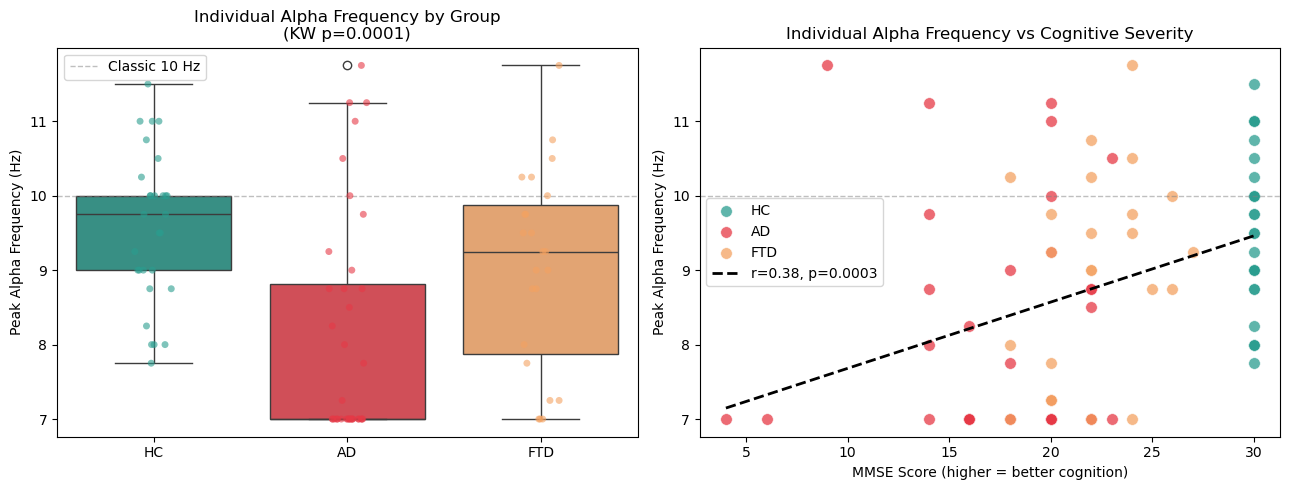

Saved: iaf_vs_mmse.png

Kruskal-Wallis: p = 0.0001
Correlation with MMSE: r = 0.377, p = 0.000297


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=iaf_df, x='group', y='IAF',
            order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS, ax=axes[0])
sns.stripplot(data=iaf_df, x='group', y='IAF',
              order=['HC', 'AD', 'FTD'], palette=GROUP_COLORS,
              alpha=0.6, size=5, jitter=True, ax=axes[0])

groups_iaf = [iaf_df[iaf_df['group'] == g]['IAF'].values for g in ['HC', 'AD', 'FTD']]
stat, p = stats.kruskal(*groups_iaf)
axes[0].set_title(f'Individual Alpha Frequency by Group\n(KW p={p:.4f})')
axes[0].set_ylabel('Peak Alpha Frequency (Hz)')
axes[0].set_xlabel('')
axes[0].axhline(y=10, color='gray', linestyle='--',
                linewidth=1, alpha=0.5, label='Classic 10 Hz')
axes[0].legend()
slope, intercept, r, p_corr, _ = stats.linregress(iaf_df['MMSE'], iaf_df['IAF'])

for grp in ['HC', 'AD', 'FTD']:
    sub = iaf_df[iaf_df['group'] == grp]
    axes[1].scatter(sub['MMSE'], sub['IAF'],
                    label=grp, color=GROUP_COLORS[grp],
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)

x_line = np.linspace(iaf_df['MMSE'].min(), iaf_df['MMSE'].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept,
             'k--', linewidth=2, label=f'r={r:.2f}, p={p_corr:.4f}')
axes[1].axhline(y=10, color='gray', linestyle='--',
                linewidth=1, alpha=0.5)
axes[1].set_xlabel('MMSE Score (higher = better cognition)')
axes[1].set_ylabel('Peak Alpha Frequency (Hz)')
axes[1].set_title('Individual Alpha Frequency vs Cognitive Severity')
axes[1].legend()

plt.tight_layout()
plt.savefig('iaf_vs_mmse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: iaf_vs_mmse.png')
print(f'\nKruskal-Wallis: p = {p:.4f}')
print(f'Correlation with MMSE: r = {r:.3f}, p = {p_corr:.6f}')

In [86]:
biomarker_df = df_subj[['subject', 'group', 'MMSE', 'Age', 'Theta_Alpha_Ratio']].copy()
biomarker_df = biomarker_df.merge(
    iaf_df[['subject', 'IAF']], on='subject', how='left'
)
biomarker_df = biomarker_df.merge(
    plv_df[['subject', 'mean_plv']], on='subject', how='left'
)
print('Biomarker dataframe:')
print(biomarker_df.head())
print(f'\nShape: {biomarker_df.shape}')

Biomarker dataframe:
   subject group  MMSE  Age  Theta_Alpha_Ratio   IAF  mean_plv
0  sub-001    AD    16   57           3.496894  7.00  0.685528
1  sub-002    AD    22   78           0.348281  8.50  0.691045
2  sub-003    AD    14   70           0.615235  8.75  0.713140
3  sub-004    AD    20   67           4.072401  7.00  0.617873
4  sub-005    AD    22   70           1.530810  7.00  0.660947

Shape: (88, 7)


In [89]:
biomarkers = {
    'Theta_Alpha_Ratio': 'Theta/Alpha Ratio',
    'IAF': 'Individual Alpha Frequency',
    'mean_plv': 'Alpha PLV'
}
print('=' * 60)
print('PARTIAL CORRELATIONS WITH MMSE (controlling for Age)')
print('=' * 60)
for col, name in biomarkers.items():
    r_simple, p_simple = stats.pearsonr(biomarker_df[col], biomarker_df['MMSE'])
    result = pg.partial_corr(
        data=biomarker_df,
        x=col,
        y='MMSE',
        covar='Age'
    )
    r_partial = result['r'].values[0]
    p_partial = result['p_val'].values[0]
    print(f'\n{name}:')
    print(f'  Simple correlation:  r = {r_simple:.3f}, p = {p_simple:.6f}')
    print(f'  Age-corrected:       r = {r_partial:.3f}, p = {p_partial:.6f}')
    if abs(r_partial) >= abs(r_simple):
        print(f'  → Relationship STRONGER after age correction')
    else:
        print(f'  → Relationship slightly weaker but still holds')
print('\n' + '=' * 60)
print('CORRELATION BETWEEN AGE AND MMSE (to check confound)')
r_age, p_age = stats.pearsonr(biomarker_df['Age'], biomarker_df['MMSE'])
print(f'Age vs MMSE: r = {r_age:.3f}, p = {p_age:.4f}')
if p_age > 0.05:
    print('Age is NOT significantly correlated with MMSE in this dataset')
    print('→ Age confound is minimal, original results stand as-is')
else:
    print('Age IS correlated with MMSE — age correction was important')

PARTIAL CORRELATIONS WITH MMSE (controlling for Age)

Theta/Alpha Ratio:
  Simple correlation:  r = -0.501, p = 0.000001
  Age-corrected:       r = -0.488, p = 0.000002
  → Relationship slightly weaker but still holds

Individual Alpha Frequency:
  Simple correlation:  r = 0.377, p = 0.000297
  Age-corrected:       r = 0.372, p = 0.000385
  → Relationship slightly weaker but still holds

Alpha PLV:
  Simple correlation:  r = 0.285, p = 0.007221
  Age-corrected:       r = 0.268, p = 0.012043
  → Relationship slightly weaker but still holds

CORRELATION BETWEEN AGE AND MMSE (to check confound)
Age vs MMSE: r = 0.158, p = 0.1412
Age is NOT significantly correlated with MMSE in this dataset
→ Age confound is minimal, original results stand as-is
